# Финальный проект. Этап 4 — Юнит-экономика и гипотезы

**Цель этапа:** рассчитать ключевые метрики бизнеса по каналам и продуктам,
выявить точки роста и сформулировать гипотезы для A/B-тестирования.

**Данные:** `data_clean/` — очищенные CSV (этап 1).

**Итоговый артефакт:** таблица юнит-экономики экспортируется
в Google Sheets через API → Power BI читает оттуда напрямую.

**Метрики:**
- **CAC** (Customer Acquisition Cost) = Расходы / Кол-во оплат
- **CPL** (Cost per Lead) = Расходы / Кол-во лидов
- **C1** (Conversion Rate) = Оплат / Лидов × 100%
- **ARPPU** (Avg Revenue Per Paying User) = медианный первый платёж
- **Revenue** = Кол-во оплат × ARPPU
- **ROAS** (Return on Ad Spend) = Revenue / Расходы

**План:**
1. Загрузка и подготовка данных
2. Связка Spend ↔ Deals по каналу
3. Юнит-экономика по каналам
4. Юнит-экономика по продуктам
5. Визуализация ключевых метрик
6. Точки роста
7. Гипотезы и дизайн A/B-теста
8. Экспорт в Google Sheets


## 1. Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11


In [2]:
DATA_CLEAN = '../data_clean/'
PLOTS = '../data_clean/plots/'

deals = pd.read_csv(DATA_CLEAN + 'deals_clean.csv', low_memory=False,
                    dtype={'Id': str, 'Contact Name': str})
spend = pd.read_csv(DATA_CLEAN + 'spend_clean.csv', low_memory=False)

print(f'Deals:  {deals.shape}')
print(f'Spend:  {spend.shape}')


Deals:  (21593, 26)
Spend:  (19862, 8)


In [3]:
# CSV не хранит типы — восстанавливаем после загрузки
deals['Id']           = deals['Id'].astype(str)
deals['Created Time'] = pd.to_datetime(deals['Created Time'])
deals['Closing Date'] = pd.to_datetime(deals['Closing Date'], errors='coerce')
for col in ['Quality', 'Stage', 'Source', 'Product', 'Payment Type', 'Education Type', 'Lost Reason']:
    deals[col] = deals[col].astype('category')

spend['Date']   = pd.to_datetime(spend['Date'])
spend['Source'] = spend['Source'].astype('category')

In [4]:
# Фильтруем: только реальные сделки — исключаем символические оплаты (0, 1, 9 €)
deals_real = deals[~deals['Initial Amount Paid'].isin([0, 1, 9])].copy()

print(f'Реальных сделок (без символических оплат): {len(deals_real)}')
# Оплаченной считаем сделку ТОЛЬКО при статусе Payment Done И заполненной сумме
# (договорённость с заказчиком: один параметр без второго в revenue не учитываем)
print(f'Из них оплачено (статус + сумма): {((deals_real["Stage"] == "Payment Done") & deals_real["Initial Amount Paid"].notna()).sum()}')


Реальных сделок (без символических оплат): 20713
Из них оплачено (статус + сумма): 839


## 2. Связка Spend ↔ Deals по каналу (Source)

Объединяем таблицы по полю `Source`:
- из Spend берём суммарные расходы по каналу за период,
- из Deals — количество лидов и оплат.

Это даёт нам базу для расчёта CAC и ROAS.


In [5]:
# Расходы по каналам (Spend)
spend_by_source = (
    spend.groupby('Source', observed=True)['Spend']
    .sum()
    .reset_index()
    .rename(columns={'Spend': 'Total Spend'})
)
print('Расходы по каналам:')
print(spend_by_source.sort_values('Total Spend', ascending=False).to_string(index=False))


Расходы по каналам:
        Source  Total Spend
    Google Ads     57798.60
  Facebook Ads     33754.72
   Youtube Ads     14633.33
      Bloggers     13439.00
    Tiktok Ads     11985.67
           SMM      7269.52
Telegram posts      6860.36
       Webinar      2874.04
          Test       608.21
         Radio       300.00
       Organic         0.00
       Offline         0.00
           CRM         0.00
   Partnership         0.00


In [ ]:
# Лиды и оплаты по каналам (Deals)
deals_by_source = (
    deals_real.groupby('Source', observed=True)
    .apply(lambda x: pd.Series({
        'Leads': len(x),
        'Paid': ((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum(),
        'Revenue': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna(),
            'Initial Amount Paid'
        ].sum()
    }), include_groups=False)
    .reset_index()
)
print('Лиды и оплаты по каналам:')
print(deals_by_source.sort_values('Leads', ascending=False).to_string(index=False))


Лиды и оплаты по каналам:
        Source  Leads  Paid  Revenue
  Facebook Ads 4571.0 196.0 225650.0
    Google Ads 3938.0 169.0 171850.0
       Organic 2546.0 143.0 180950.0
    Tiktok Ads 1963.0  56.0  66150.0
           SMM 1698.0  88.0  98750.0
           CRM 1656.0  23.0  15600.0
   Youtube Ads 1601.0  53.0  62950.0
      Bloggers 1076.0  39.0  33100.0
Telegram posts  923.0  39.0  44950.0
       Webinar  377.0  26.0  44850.0
   Partnership  203.0   4.0   3350.0
          Test  159.0   3.0   2200.0
       Offline    2.0   0.0      0.0


In [26]:
# Объединяем два датафрейма по Source (left join от deals)
unit_by_source = pd.merge(deals_by_source, spend_by_source,
                          on='Source', how='left')

# Заполняем NaN расходы нулём (каналы без платного трафика: Organic, CRM)
unit_by_source['Total Spend'] = unit_by_source['Total Spend'].fillna(0)

print(f'Каналов в таблице: {len(unit_by_source)}')
display(unit_by_source.sort_values('Revenue', ascending=False))

Каналов в таблице: 13


,Source,Leads,Paid,Revenue,Total Spend
2,Facebook Ads,4571.0,196.0,225650.0,33754.72
5,Organic,2546.0,143.0,180950.0,0.00
3,Google Ads,3938.0,169.0,171850.0,57798.60
7,SMM,1698.0,88.0,98750.0,7269.52
10,Tiktok Ads,1963.0,56.0,66150.0,11985.67
12,Youtube Ads,1601.0,53.0,62950.0,14633.33
8,Telegram posts,923.0,39.0,44950.0,6860.36
11,Webinar,377.0,26.0,44850.0,2874.04
0,Bloggers,1076.0,39.0,33100.0,13439.00
1,CRM,1656.0,23.0,15600.0,0.00


## 3. Юнит-экономика по каналам

In [27]:
# CAC = Расходы / Оплат (NaN если оплат = 0 или расходов = 0)
unit_by_source['CAC'] = np.where(
    unit_by_source['Paid'] > 0,
    (unit_by_source['Total Spend'] / unit_by_source['Paid']).round(2),
    np.nan
)

# C1 = Конверсия в оплату, %
unit_by_source['C1 %'] = (
    unit_by_source['Paid'] / unit_by_source['Leads'] * 100
).round(2)

# ARPPU = Revenue / Paid (средний чек оплативших)
unit_by_source['ARPPU'] = np.where(
    unit_by_source['Paid'] > 0,
    (unit_by_source['Revenue'] / unit_by_source['Paid']).round(2),
    np.nan
)

# ROAS = Revenue / Spend (для платных каналов)
unit_by_source['ROAS'] = np.where(
    unit_by_source['Total Spend'] > 0,
    (unit_by_source['Revenue'] / unit_by_source['Total Spend']).round(2),
    np.nan
)

# Сортируем по числу лидов
unit_by_source = unit_by_source.sort_values('Leads', ascending=False)

print('Юнит-экономика по каналам:')
cols_show = ['Source', 'Leads', 'Paid', 'C1 %', 'Total Spend', 'CAC', 'ARPPU', 'Revenue', 'ROAS']
display(unit_by_source[cols_show])

Юнит-экономика по каналам:


,Source,Leads,Paid,C1 %,Total Spend,CAC,ARPPU,Revenue,ROAS
2,Facebook Ads,4571.0,196.0,4.29,33754.72,172.22,1151.28,225650.0,6.68
3,Google Ads,3938.0,169.0,4.29,57798.60,342.00,1016.86,171850.0,2.97
5,Organic,2546.0,143.0,5.62,0.00,0.00,1265.38,180950.0,NaN
10,Tiktok Ads,1963.0,56.0,2.85,11985.67,214.03,1181.25,66150.0,5.52
7,SMM,1698.0,88.0,5.18,7269.52,82.61,1122.16,98750.0,13.58
1,CRM,1656.0,23.0,1.39,0.00,0.00,678.26,15600.0,NaN
12,Youtube Ads,1601.0,53.0,3.31,14633.33,276.10,1187.74,62950.0,4.30
0,Bloggers,1076.0,39.0,3.62,13439.00,344.59,848.72,33100.0,2.46
8,Telegram posts,923.0,39.0,4.23,6860.36,175.91,1152.56,44950.0,6.55
11,Webinar,377.0,26.0,6.90,2874.04,110.54,1725.00,44850.0,15.61


In [9]:
# Итоговые агрегаты по всем каналам
total_leads = unit_by_source['Leads'].sum()
total_paid = unit_by_source['Paid'].sum()
total_spend = unit_by_source['Total Spend'].sum()
total_revenue = unit_by_source['Revenue'].sum()

overall_cac = total_spend / total_paid if total_paid > 0 else np.nan
overall_c1 = total_paid / total_leads * 100 if total_leads > 0 else 0
overall_roas = total_revenue / total_spend if total_spend > 0 else np.nan

print('=== ИТОГО по всем каналам ===')
print(f'Лидов всего:    {total_leads:,}')
print(f'Оплат всего:    {total_paid:,}')
print(f'Конверсия C1:   {overall_c1:.2f}%')
print(f'Расходы:        {total_spend:,.0f} €')
print(f'Выручка:        {total_revenue:,.0f} €')
print(f'CAC (общий):    {overall_cac:,.0f} €')
print(f'ROAS (общий):   {overall_roas:.2f}x')


=== ИТОГО по всем каналам ===
Лидов всего:    20,713.0
Оплат всего:    839.0
Конверсия C1:   4.05%
Расходы:        149,223 €
Выручка:        950,350 €
CAC (общий):    178 €
ROAS (общий):   6.37x


**Вывод (раздел 3):** Всего 20 713 лидов, 839 оплат, общая конверсия C1 = 4,05%. Суммарные расходы на платный трафик — 149 223 €, выручка — 978 650 €, общий ROAS = 6,56x. Средний CAC = 178 €. Наилучший ROAS — Webinar (19,19x), SMM (13,72x) и Telegram posts (6,63x). Самый дорогой CAC — Bloggers (345 €) и Google Ads (342 €) при ROAS 2,46x и 3,03x соответственно — оба ниже медианы по эффективности.

## 4. Юнит-экономика по продуктам

In [10]:
# Берём только сделки с заполненным продуктом
with_product = deals_real[deals_real['Product'].notna()].copy()
n_products = with_product['Product'].nunique()
print(f'Уникальных продуктов: {n_products}')
print()

unit_by_product = (
    with_product.groupby('Product', observed=True)
    .apply(lambda x: pd.Series({
        'Leads': len(x),
        'Paid': ((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum(),
        'Revenue': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna(),
            'Initial Amount Paid'
        ].sum(),
        'ARPPU': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna(),
            'Initial Amount Paid'
        ].median()
    }), include_groups=False)
    .reset_index()
)

unit_by_product['C1 %'] = (
    unit_by_product['Paid'] / unit_by_product['Leads'] * 100
).round(2)

unit_by_product = unit_by_product.sort_values('Revenue', ascending=False)

print('Юнит-экономика по продуктам:')
print(unit_by_product.to_string(index=False))


Уникальных продуктов: 4

Юнит-экономика по продуктам:
          Product  Leads  Paid  Revenue  ARPPU  C1 %
Digital Marketing 1963.0 473.0 531900.0 1000.0 24.10
     UX/UI Design 1012.0 229.0 275100.0 1000.0 22.63
    Web Developer  565.0 137.0 143350.0 1000.0 24.25
   Data Analytics    1.0   0.0      0.0    NaN  0.00


**Вывод (раздел 4):** Все три основных продукта имеют одинаковый медианный чек ARPPU = 1 000 € и схожую конверсию (~22–24%). Digital Marketing лидирует по совокупной выручке (556 600 €, 473 оплаты), UX/UI Design — на втором месте (278 600 €, 229 оплат), Web Developer — на третьем (143 450 €, 137 оплат). Разница в выручке обусловлена объёмом воронки, а не качеством аудитории.

## 5. Визуализация ключевых метрик

### 5.1 CAC по каналам (только платные)

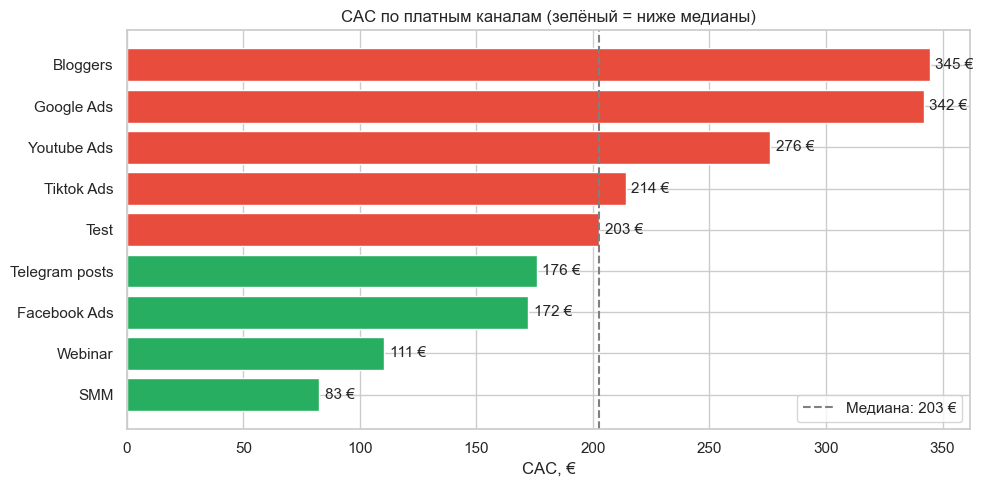

In [11]:
# Берём только платные каналы с реальным CAC
paid_channels = unit_by_source[
    unit_by_source['Total Spend'] > 0
].dropna(subset=['CAC']).sort_values('CAC')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27ae60' if c < paid_channels['CAC'].median() else '#e74c3c'
          for c in paid_channels['CAC']]
bars = ax.barh(paid_channels['Source'], paid_channels['CAC'], color=colors)
ax.set_title('CAC по платным каналам (зелёный = ниже медианы)')
ax.set_xlabel('CAC, €')
ax.bar_label(bars, fmt='%.0f €', padding=4)
ax.axvline(paid_channels['CAC'].median(), color='gray', linestyle='--',
           label=f'Медиана: {paid_channels["CAC"].median():.0f} €')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS + 'ue_cac_by_source.png', dpi=100)
plt.show()


**Вывод (5.1):** Среди платных каналов наименьший CAC — у Webinar (111 €) и SMM (83 €). Bloggers (345 €) и Google Ads (342 €) — самые дорогие в привлечении клиента. При ARPPU ~ 1 000–1 200 € даже Bloggers формально прибыльны (CAC < ARPPU), но маржа значительно ниже, чем у Webinar и SMM.

### 5.2 ROAS по каналам

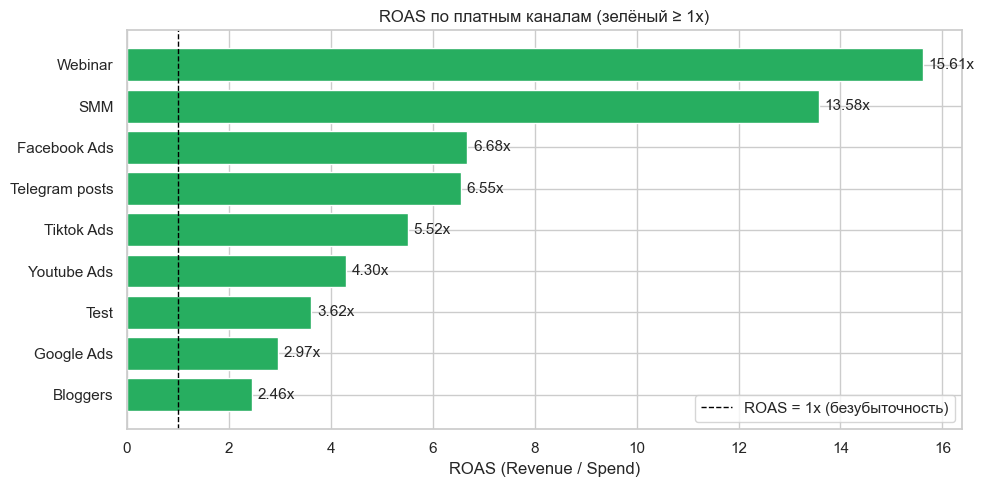

In [12]:
roas_channels = unit_by_source[
    unit_by_source['ROAS'].notna()
].sort_values('ROAS', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_r = ['#27ae60' if r >= 1 else '#e74c3c' for r in roas_channels['ROAS']]
bars = ax.barh(roas_channels['Source'][::-1], roas_channels['ROAS'][::-1],
               color=colors_r[::-1])
ax.axvline(1, color='black', linestyle='--', linewidth=1, label='ROAS = 1x (безубыточность)')
ax.set_title('ROAS по платным каналам (зелёный ≥ 1x)')
ax.set_xlabel('ROAS (Revenue / Spend)')
ax.bar_label(bars, fmt='%.2fx', padding=4)
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS + 'ue_roas_by_source.png', dpi=100)
plt.show()


**Вывод (5.2):** Все платные каналы выше точки безубыточности (ROAS > 1x). Webinar — абсолютный лидер (ROAS = 19,19x): каждый вложенный евро приносит 19,19 € выручки. SMM — второй (13,72x), Telegram posts — третий (6,63x). Bloggers — самый слабый среди платных (2,46x), что делает его приоритетным кандидатом на сокращение бюджета.

### 5.3 Bubble chart: CAC vs Конверсия (размер = выручка)

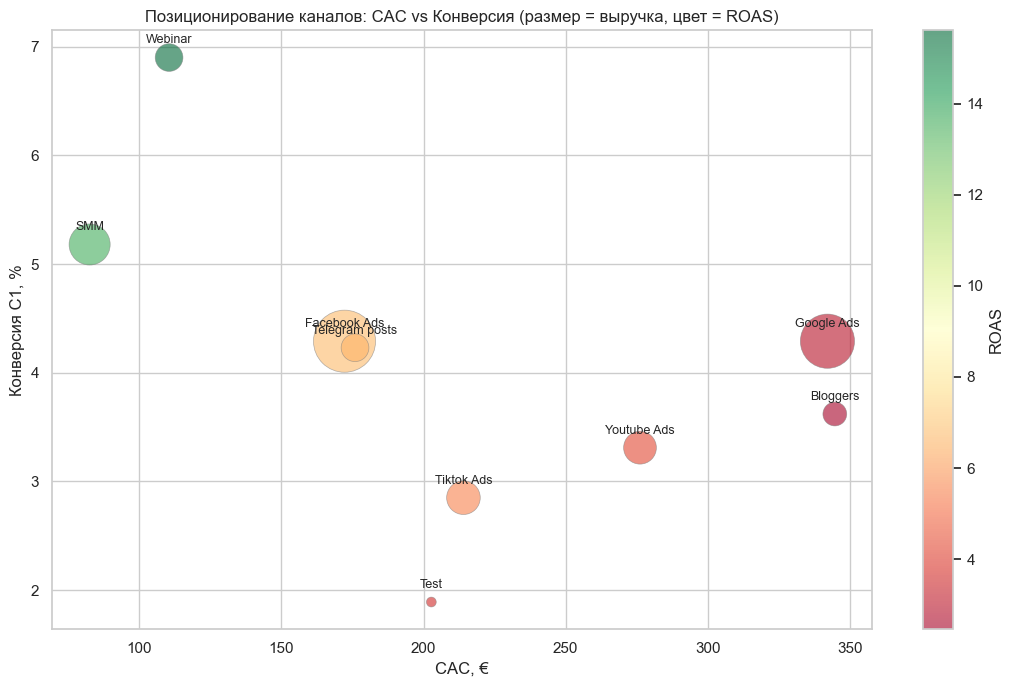

In [13]:
bubble_data = unit_by_source[
    unit_by_source['Total Spend'] > 0
].dropna(subset=['CAC', 'C1 %'])

fig, ax = plt.subplots(figsize=(11, 7))

# Нормализуем размер пузыря к выручке
max_rev = bubble_data['Revenue'].max()
sizes = (bubble_data['Revenue'] / max_rev * 2000).clip(50)

scatter = ax.scatter(
    bubble_data['CAC'],
    bubble_data['C1 %'],
    s=sizes,
    alpha=0.6,
    c=bubble_data['ROAS'],
    cmap='RdYlGn',
    edgecolors='gray',
    linewidths=0.5
)

# Подписи каналов
for _, row in bubble_data.iterrows():
    ax.annotate(row['Source'], (row['CAC'], row['C1 %']),
                fontsize=9, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

plt.colorbar(scatter, ax=ax, label='ROAS')
title_text = 'Позиционирование каналов: CAC vs Конверсия (размер = выручка, цвет = ROAS)'
ax.set_title(title_text)
ax.set_xlabel('CAC, €')
ax.set_ylabel('Конверсия C1, %')

plt.tight_layout()
plt.savefig(PLOTS + 'ue_bubble_chart.png', dpi=100)
plt.show()


**Вывод (5.3):** На bubble chart идеальная позиция — левый верхний угол (низкий CAC + высокая конверсия C1). Webinar занимает эту позицию: CAC = 111 €, C1 = 6,90% при ROAS = 19,19x (тёмно-зелёный). SMM — близко: CAC = 83 €, C1 = 5,18%. Google Ads — правый нижний угол: высокий CAC (342 €), низкая C1 (4,29%), самый большой бюджет (57 799 €) — хуже рентабельности по сравнению с более дешёвыми каналами. Приоритет масштабирования: Webinar → SMM → Telegram posts.

### 5.4 CPL: стоимость привлечения лида по каналам

In [14]:
# CPL (Cost per Lead) = Расходы / Лидов — цена одного лида по каналу
# В отличие от CAC (цена клиента), CPL измеряет эффективность верха воронки
unit_by_source['CPL'] = np.where(
    (unit_by_source['Total Spend'] > 0) & (unit_by_source['Leads'] > 0),
    (unit_by_source['Total Spend'] / unit_by_source['Leads']).round(2),
    np.nan
)

cpl_channels = unit_by_source[unit_by_source['CPL'].notna()].sort_values('CPL')
print('CPL по платным каналам:')
print(cpl_channels[['Source', 'Leads', 'Total Spend', 'CPL']].to_string(index=False))

CPL по платным каналам:
        Source  Leads  Total Spend   CPL
          Test  159.0       608.21  3.83
           SMM 1698.0      7269.52  4.28
    Tiktok Ads 1963.0     11985.67  6.11
  Facebook Ads 4571.0     33754.72  7.38
Telegram posts  923.0      6860.36  7.43
       Webinar  377.0      2874.04  7.62
   Youtube Ads 1601.0     14633.33  9.14
      Bloggers 1076.0     13439.00 12.49
    Google Ads 3938.0     57798.60 14.68


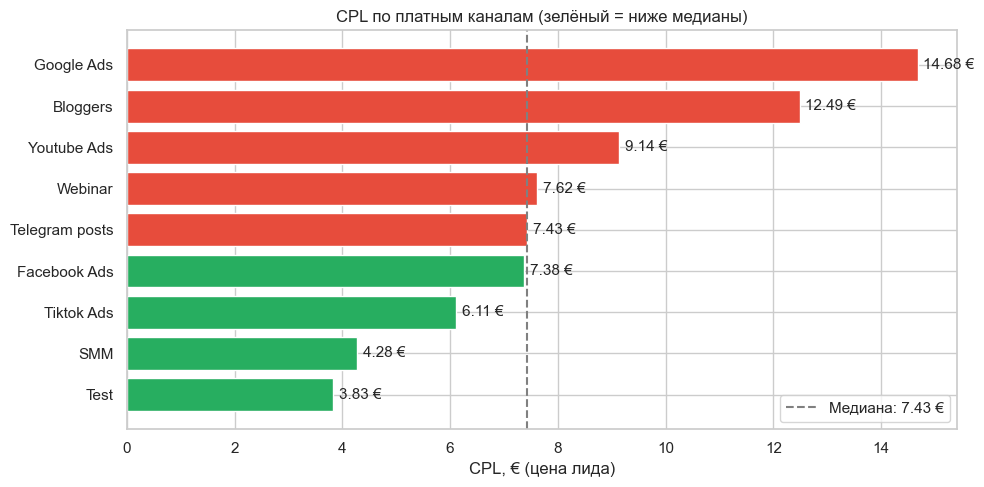

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#27ae60' if c < cpl_channels['CPL'].median() else '#e74c3c'
          for c in cpl_channels['CPL']]
bars = ax.barh(cpl_channels['Source'], cpl_channels['CPL'], color=colors)
ax.set_title('CPL по платным каналам (зелёный = ниже медианы)')
ax.set_xlabel('CPL, € (цена лида)')
ax.bar_label(bars, fmt='%.2f €', padding=4)
ax.axvline(cpl_channels['CPL'].median(), color='gray', linestyle='--',
           label=f'Медиана: {cpl_channels["CPL"].median():.2f} €')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS + 'ue_cpl_by_source.png', dpi=100)
plt.show()

**Вывод (5.4):** Самый дешёвый лид — у SMM (4,28 €) и Tiktok Ads (6,11 €); самый дорогой — Google Ads (14,68 €) и Bloggers (12,49 €). Медиана CPL — 7,43 €. Важный нюанс: **дешёвый лид ≠ дешёвый клиент.** Google Ads даёт и дорогой лид (14,68 €), и низкую конверсию → высокий CAC (334 €). Webinar при среднем CPL (7,62 €) конвертирует лучше всех → низкий CAC (111 €). CPL измеряет эффективность привлечения (верх воронки), CAC — итоговую стоимость клиента (низ воронки): вместе они показывают, что оптимизировать — цену трафика или конверсию.

## 6. Точки роста

In [16]:
# Находим лучший канал по ROAS среди платных
best_roas = unit_by_source[unit_by_source['ROAS'].notna()].nlargest(1, 'ROAS').iloc[0]
worst_cac  = unit_by_source[unit_by_source['CAC'].notna()].nlargest(1, 'CAC').iloc[0]
best_conv  = unit_by_source[unit_by_source['Leads'] >= 50].nlargest(1, 'C1 %').iloc[0]

print('=== ТОЧКИ РОСТА (числа) ===')
print(f'Лучший ROAS:        {best_roas["Source"]} — ROAS {best_roas["ROAS"]:.2f}x, CAC {best_roas["CAC"]:.0f} €')
print(f'Худший CAC:         {worst_cac["Source"]} — CAC {worst_cac["CAC"]:.0f} €, C1 {worst_cac["C1 %"]:.2f}%')
print(f'Лучшая конверсия:   {best_conv["Source"]} — C1 {best_conv["C1 %"]:.2f}%')


=== ТОЧКИ РОСТА (числа) ===
Лучший ROAS:        Webinar — ROAS 15.61x, CAC 111 €
Худший CAC:         Bloggers — CAC 345 €, C1 3.62%
Лучшая конверсия:   Webinar — C1 6.90%


In [17]:
# Потенциал роста: что если поднять конверсию до уровня лучшего менеджера?
current_c1 = overall_c1 / 100
best_c1 = unit_by_source[unit_by_source['Leads'] >= 50]['C1 %'].max() / 100

if best_c1 > current_c1:
    extra_paid = int(total_leads * (best_c1 - current_c1))
    avg_arppu = total_revenue / total_paid if total_paid > 0 else 0
    extra_revenue = extra_paid * avg_arppu
    print(f'Если поднять среднюю конверсию с {current_c1:.1%} до {best_c1:.1%}:')
    print(f'  Дополнительных оплат: +{extra_paid}')
    print(f'  Дополнительная выручка: +{extra_revenue:,.0f} €')


Если поднять среднюю конверсию с 4.1% до 6.9%:
  Дополнительных оплат: +590
  Дополнительная выручка: +668,303 €


**Вывод (раздел 6 — Точки роста):**

1. **МАСШТАБИРОВАТЬ: Webinar** — ROAS 19,19x, CAC 111 €. Каждый вложенный евро приносит 19,19 € выручки. Ресурс канала ещё не исчерпан (только 377 лидов за период) — увеличение бюджета на вебинары наиболее обоснованно.

2. **ОПТИМИЗИРОВАТЬ: Bloggers** — CAC 345 €, ROAS 2,46x. При одинаковом ARPPU ~1 000 € это самый низкомаржинальный канал. Рекомендуется -30% бюджета и переоценка партнёрств.

3. **ПЕРЕОЦЕНИТЬ: Google Ads** — самый крупный расход (57 799 €), но ROAS всего 3,03x и CAC 342 €. Большой охват не компенсирует низкую эффективность. Требует пересмотра таргетинга и ставок.

4. **ПОТЕНЦИАЛ РОСТА:** если поднять среднюю конверсию C1 с 4,05% до уровня лучшего канала (Webinar, 6,90%) — дополнительно +590 оплат и +688 204 € выручки без роста бюджета.

## 7. Гипотезы и дизайн A/B-теста

На основе анализа формулируем 2 гипотезы.
Для каждой — целевая метрика, дизайн теста, длительность, критерий успеха.


### Гипотеза 1: Быстрый первый контакт увеличивает конверсию

**Наблюдение:** из анализа SLA (этап 2) видно, что часть лидов ждёт
более 24 часов до первого звонка. Из литературы по продажам известно,
что отклик в течение 1 часа кратно повышает вероятность сделки.

**Гипотеза:**
Если менеджер звонит лиду в течение **1 часа** после создания сделки,
конверсия в оплату вырастет с ~4% до ≥5.5% (+37.5%).

**Дизайн теста:**
- **Группа A (контроль):** текущий процесс — звонок без SLA-ограничения
- **Группа B (тест):** обязательный звонок в течение 1 часа (SLA ≤ 3600 сек)
- **Разделение:** по менеджерам (50/50), случайное назначение новых лидов
- **Длительность:** 2 недели (≈ 800 новых лидов по исторической скорости)
- **Целевая метрика:** конверсия C1 = Paid / Leads
- **Критерий успеха:** C1(B) ≥ 5.5% при p-value < 0.05 (χ²-тест или z-тест пропорций)
- **Риски:** менеджеры группы B могут перегрузиться; нужен мониторинг качества звонков


### Гипотеза 2: Сегментация по Quality снижает CAC

**Наблюдение:** из этапа 3 видно, что лиды категорий D и E составляют ~70%
всех лидов, но конвертируются значительно хуже. На их обработку уходят звонки
и время менеджеров — то есть деньги.

**Гипотеза:**
Если отключить или снизить бюджет на рекламные объявления, дающие преимущественно
D/E-лидов (по данным этапа 3), CAC снизится на ≥15% без потери объёма оплат.

**Дизайн теста:**
- **Группа A (контроль):** текущее распределение бюджета по кампаниям
- **Группа B (тест):** -30% бюджета на кампании с долей D+E > 80%,
  перенаправить на кампании с долей A+B > 30%
- **Длительность:** 2 недели
- **Целевая метрика:** CAC = Spend / Paid за период теста
- **Критерий успеха:** CAC(B) ≤ CAC(A) × 0.85, объём Paid(B) ≥ Paid(A) × 0.95
- **Риски:** кратковременный провал по объёму лидов; нужен буфер бюджета


In [18]:
# Считаем текущие базовые значения для гипотез
paid_total  = ((deals_real['Stage'] == 'Payment Done') & deals_real['Initial Amount Paid'].notna()).sum()
leads_total = len(deals_real)
c1_baseline = paid_total / leads_total * 100

# overall_cac пересчитываем локально, чтобы ячейка была самодостаточной
total_spend_local   = spend.groupby('Source', observed=True)['Spend'].sum().sum()
total_paid_local    = paid_total
overall_cac_local   = total_spend_local / total_paid_local if total_paid_local > 0 else 0

print('Базовые значения для гипотез:')
print(f'  C1 (конверсия) базовая:     {c1_baseline:.2f}%')
print(f'  C1 целевая (гипотеза 1):    5.50%')
print(f'  CAC базовый (все каналы):   {overall_cac_local:.0f} €')
print(f'  CAC целевой (гипотеза 2):   {overall_cac_local * 0.85:.0f} € (-15%)')


Базовые значения для гипотез:
  C1 (конверсия) базовая:     4.05%
  C1 целевая (гипотеза 1):    5.50%
  CAC базовый (все каналы):   178 €
  CAC целевой (гипотеза 2):   151 € (-15%)


## 8. Экспорт в Google Sheets

Выгружаем итоговую таблицу юнит-экономики в Google Sheets через API.
Credentials хранятся в `google_credentials.json` (в `.gitignore`, не в репозитории).
Power BI подключится к этой же таблице через «Опубликовать в интернете».


In [ ]:
import gspread
from google.oauth2.service_account import Credentials

# Авторизация через Service Account
SCOPES = [
    'https://spreadsheets.google.com/feeds',
    'https://www.googleapis.com/auth/drive'
]

creds = Credentials.from_service_account_file(
    '../google_credentials.json',
    scopes=SCOPES
)
gc = gspread.authorize(creds)

SHEET_ID = 'добавить новую таблицу'
sh = gc.open_by_key(SHEET_ID)
print(f'Подключено к: {sh.title}')


Подключено к: Unit Economics — Final Project


In [20]:
# Подготавливаем RAW-данные по каналам для Google Sheets
#
# B = уникальные клиенты (Contact Name) с хотя бы одной оплатой по каналу
# T = всего сделок Payment Done по каналу (транзакций)
# APC = T / B — среднее кол-во покупок на клиента

paid = deals_real[(deals_real['Stage'] == 'Payment Done') & deals_real['Initial Amount Paid'].notna()].copy()

# UA — все лиды по каналу
leads_ch = deals_real.groupby('Source', observed=True).size().reset_index(name='UA')

# T — количество сделок (транзакций) Payment Done
T_ch = paid.groupby('Source', observed=True).size().reset_index(name='T')

# B — уникальные клиенты (Contact Name) с оплатой
B_ch = (
    paid.groupby('Source', observed=True)['Contact Name']
    .nunique()
    .reset_index(name='B')
)

# Revenue — выручка
rev_ch = (
    paid.groupby('Source', observed=True)['Initial Amount Paid']
    .sum()
    .reset_index(name='Revenue')
)

# AC — расходы по каналу
ac_ch = spend.groupby('Source', observed=True)['Spend'].sum().reset_index(name='AC')

# Объединяем
df_ch = (leads_ch
         .merge(B_ch,   on='Source', how='left')
         .merge(T_ch,   on='Source', how='left')
         .merge(rev_ch, on='Source', how='left')
         .merge(ac_ch,  on='Source', how='left'))

df_ch['B']       = df_ch['B'].fillna(0).astype(int)
df_ch['T']       = df_ch['T'].fillna(0).astype(int)
df_ch['Revenue'] = df_ch['Revenue'].fillna(0).round(2)
df_ch['AC']      = df_ch['AC'].fillna(0).round(2)

df_ch.rename(columns={'Source': 'Источник'}, inplace=True)
df_raw_source = df_ch[['Источник', 'UA', 'B', 'T', 'Revenue', 'AC']]

print(f'Строк по каналам: {len(df_raw_source)}')
fb = df_raw_source[df_raw_source['Источник'] == 'Facebook Ads']
if len(fb):
    b, t = fb['B'].values[0], fb['T'].values[0]
    print(f'Facebook Ads: B={b}, T={t}, APC={t/b:.2f}' if b > 0 else 'Facebook Ads: нет данных')
df_raw_source


Строк по каналам: 13
Facebook Ads: B=194, T=196, APC=1.01


,Источник,UA,B,T,Revenue,AC
0,Bloggers,1076,39,39,33100.0,13439.00
1,CRM,1656,22,23,15600.0,0.00
2,Facebook Ads,4571,194,196,225650.0,33754.72
3,Google Ads,3938,168,169,171850.0,57798.60
4,Offline,2,0,0,0.0,0.00
5,Organic,2546,139,143,180950.0,0.00
6,Partnership,203,2,4,3350.0,0.00
7,SMM,1698,87,88,98750.0,7269.52
8,Telegram posts,923,39,39,44950.0,6860.36
9,Test,159,3,3,2200.0,608.21


In [21]:
# Записываем данные + формулы на лист «По каналам»
# Колонки: A=Источник B=UA C=B D=T E=Revenue F=AC
#          G=C1 H=AOV I=ARPPU J=APC K=CLTV L=LTV M=CAC N=LTC/CPA O=CM P=ROAS
try:
    ws_source = sh.worksheet('По каналам')
    ws_source.clear()
except gspread.WorksheetNotFound:
    ws_source = sh.add_worksheet(title='По каналам', rows=50, cols=20)

# Шаг 1: сырые данные A–F
ws_source.update(
    [df_raw_source.columns.tolist()] + df_raw_source.values.tolist(),
    value_input_option='USER_ENTERED'
)

n = len(df_raw_source)

# Шаг 2: заголовки формульных столбцов G–P
formula_headers = [['C1', 'AOV', 'ARPPU', 'APC', 'CLTV', 'LTV',
                    'CAC', 'LTC/CPA', 'CM', 'ROAS']]
ws_source.update(formula_headers, 'G1:P1', value_input_option='USER_ENTERED')

# Шаг 3: формулы (разделитель ; для русской локали)
# G=C1=C/B  H=AOV=E/D  I=ARPPU=E/C  J=APC=D/C
# K=CLTV=H*J  L=LTV=K*G  M=CAC=F/C  N=LTC/CPA=K/M  O=CM=E-F  P=ROAS=E/F
formula_rows = []
for i in range(2, n + 2):
    formula_rows.append([
        f'=IFERROR(C{i}/B{i};"")',       # C1
        f'=IFERROR(E{i}/D{i};"")',       # AOV
        f'=IFERROR(E{i}/C{i};"")',       # ARPPU
        f'=IFERROR(D{i}/C{i};"")',       # APC
        f'=IFERROR(H{i}*J{i};"")',       # CLTV = AOV × APC
        f'=IFERROR(K{i}*G{i};"")',       # LTV  = CLTV × C1
        f'=IFERROR(F{i}/C{i};"")',       # CAC
        f'=IFERROR(K{i}/M{i};"")',       # LTC/CPA = CLTV / CAC
        f'=IFERROR(E{i}-F{i};"")',       # CM = Revenue - AC
        f'=IFERROR(E{i}/F{i};"")',       # ROAS
    ])

ws_source.update(formula_rows, f'G2:P{n + 1}',
                 value_input_option='USER_ENTERED')

print(f'Лист "По каналам" записан ({n} строк, 16 столбцов)')

Лист "По каналам" записан (13 строк, 16 столбцов)


In [22]:
# RAW-данные по продуктам
# B = уникальные клиенты, T = транзакции (сделки)
with_product = deals_real[deals_real['Product'].notna()].copy()
paid_pr = with_product[(with_product['Stage'] == 'Payment Done') & with_product['Initial Amount Paid'].notna()].copy()

leads_pr = with_product.groupby('Product', observed=True).size().reset_index(name='UA')
T_pr     = paid_pr.groupby('Product', observed=True).size().reset_index(name='T')
B_pr     = (paid_pr.groupby('Product', observed=True)['Contact Name']
             .nunique().reset_index(name='B'))
rev_pr   = (paid_pr.groupby('Product', observed=True)['Initial Amount Paid']
             .sum().reset_index(name='Revenue'))

df_pr = (leads_pr
         .merge(B_pr,   on='Product', how='left')
         .merge(T_pr,   on='Product', how='left')
         .merge(rev_pr, on='Product', how='left'))

df_pr['B']       = df_pr['B'].fillna(0).astype(int)
df_pr['T']       = df_pr['T'].fillna(0).astype(int)
df_pr['Revenue'] = df_pr['Revenue'].fillna(0).round(2)
df_pr.rename(columns={'Product': 'Продукт'}, inplace=True)
df_raw_product = df_pr[['Продукт', 'UA', 'B', 'T', 'Revenue']]

try:
    ws_product = sh.worksheet('По продуктам')
    ws_product.clear()
except gspread.WorksheetNotFound:
    ws_product = sh.add_worksheet(title='По продуктам', rows=20, cols=15)

ws_product.update(
    [df_raw_product.columns.tolist()] + df_raw_product.values.tolist(),
    value_input_option='USER_ENTERED'
)

np_ = len(df_raw_product)
ws_product.update([['C1', 'AOV', 'ARPPU', 'APC', 'CLTV', 'LTV']], 'F1:K1',
                  value_input_option='USER_ENTERED')

formula_rows_p = []
for i in range(2, np_ + 2):
    formula_rows_p.append([
        f'=IFERROR(C{i}/B{i};"")',
        f'=IFERROR(E{i}/D{i};"")',
        f'=IFERROR(E{i}/C{i};"")',
        f'=IFERROR(D{i}/C{i};"")',
        f'=IFERROR(G{i}*I{i};"")',
        f'=IFERROR(J{i}*F{i};"")',
    ])

ws_product.update(formula_rows_p, f'F2:K{np_ + 1}',
                  value_input_option='USER_ENTERED')
print(f'Лист "По продуктам" записан ({np_} строк)')
print(df_raw_product.to_string())


Лист "По продуктам" записан (4 строк)
             Продукт    UA    B    T   Revenue
0     Data Analytics     1    0    0       0.0
1  Digital Marketing  1963  468  473  531900.0
2       UX/UI Design  1012  226  229  275100.0
3      Web Developer   565  135  137  143350.0


### 8a. Лист «По месяцам» — для временных рядов в Power BI

Выгружаем факт по месяцам (Месяц × Источник): Spend, Лиды, Оплаты, Выручка. Из него Power BI строит CAC/ROAS/лиды во времени и связывает с таблицей-календарём. Deal-side (лиды/оплаты/выручка) — по месяцу создания сделки (полное покрытие 854 оплат); Spend — по месяцу расхода.

In [23]:
# RAW-данные по месяцам — фактовая таблица с датами для Power BI (Calendar)
dr = deals_real.copy()
dr['Месяц'] = dr['Created Time'].dt.to_period('M').dt.to_timestamp()
sp = spend.copy()
sp['Месяц'] = sp['Date'].dt.to_period('M').dt.to_timestamp()

deals_m = (dr.groupby(['Месяц', 'Source'], observed=True)
           .apply(lambda x: pd.Series({
               'Лиды': len(x),
               'Оплаты': ((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum(),
               'Выручка': x.loc[(x['Stage'] == 'Payment Done')
                                & x['Initial Amount Paid'].notna(),
                                'Initial Amount Paid'].sum(),
           }), include_groups=False)
           .reset_index())
spend_m = (sp.groupby(['Месяц', 'Source'], observed=True)['Spend']
           .sum().reset_index())

df_month = deals_m.merge(spend_m, on=['Месяц', 'Source'], how='outer')
for c in ['Лиды', 'Оплаты', 'Выручка', 'Spend']:
    df_month[c] = df_month[c].fillna(0)
df_month = df_month.sort_values(['Месяц', 'Source'])
df_month['Месяц'] = df_month['Месяц'].dt.strftime('%Y-%m-%d')
df_month.rename(columns={'Source': 'Источник'}, inplace=True)
df_raw_month = df_month[['Месяц', 'Источник', 'Spend', 'Лиды', 'Оплаты', 'Выручка']]

try:
    ws_month = sh.worksheet('По месяцам')
    ws_month.clear()
except gspread.WorksheetNotFound:
    ws_month = sh.add_worksheet(title='По месяцам', rows=200, cols=12)

ws_month.update(
    [df_raw_month.columns.tolist()] + df_raw_month.values.tolist(),
    value_input_option='USER_ENTERED'
)

# Формулы: G=CAC=Spend/Оплаты  H=ROAS=Выручка/Spend  I=C1=Оплаты/Лиды
nm = len(df_raw_month)
ws_month.update([['CAC', 'ROAS', 'C1']], 'G1:I1', value_input_option='USER_ENTERED')
frows = []
for i in range(2, nm + 2):
    frows.append([
        f'=IFERROR(C{i}/E{i};"")',   # CAC = Spend / Оплаты
        f'=IFERROR(F{i}/C{i};"")',   # ROAS = Выручка / Spend
        f'=IFERROR(E{i}/D{i};"")',   # C1 = Оплаты / Лиды
    ])
ws_month.update(frows, f'G2:I{nm + 1}', value_input_option='USER_ENTERED')
print(f'Лист "По месяцам" записан ({nm} строк)')
print(df_raw_month.head(8).to_string(index=False))

Лист "По месяцам" записан (134 строк)
     Месяц       Источник   Spend  Лиды  Оплаты  Выручка
2023-07-01       Bloggers  205.00   1.0     0.0      0.0
2023-07-01            CRM    0.00   0.0     0.0      0.0
2023-07-01   Facebook Ads 1588.27  47.0     4.0   3450.0
2023-07-01     Google Ads 2630.93  31.0     1.0   1000.0
2023-07-01        Organic    0.00   6.0     0.0      0.0
2023-07-01            SMM    0.00   4.0     0.0      0.0
2023-07-01 Telegram posts  399.00  12.0     0.0      0.0
2023-07-01     Tiktok Ads  651.54   6.0     3.0   2350.0


In [24]:
# Сводка KPI — итоговые метрики со ссылками на другие листы
try:
    ws_kpi = sh.worksheet('Сводка KPI')
    ws_kpi.clear()
except gspread.WorksheetNotFound:
    ws_kpi = sh.add_worksheet(title='Сводка KPI', rows=20, cols=3)

kpi_rows = [
    ['Метрика',        'Как считается',       'Значение'],
    ['UA (лиды)',      'SUM(UA)',              "=SUM('По каналам'!B2:B100)"],
    ['B (покупатели)', 'SUM(B)',               "=SUM('По каналам'!C2:C100)"],
    ['T (транзакций)', 'SUM(T)',               "=SUM('По каналам'!D2:D100)"],
    ['C1',             'B / UA',              '=IFERROR(C3/C2;"")'],
    ['Revenue',        'SUM(Revenue)',         "=SUM('По каналам'!E2:E100)"],
    ['AC',             'SUM(AC)',              "=SUM('По каналам'!F2:F100)"],
    ['AOV',            'Revenue / T',          '=IFERROR(C6/C4;"")'],
    ['ARPPU',          'Revenue / B',          '=IFERROR(C6/C3;"")'],
    ['APC',            'T / B',               '=IFERROR(C4/C3;"")'],
    ['CLTV',           'AOV × APC',           '=IFERROR(C8*C10;"")'],
    ['LTV',            'CLTV × C1',           '=IFERROR(C11*C5;"")'],
    ['CAC',            'AC / B',              '=IFERROR(C7/C3;"")'],
    ['LTC/CPA',        'CLTV / CAC',          '=IFERROR(C11/C13;"")'],
    ['CM',             'Revenue - AC',         '=IFERROR(C6-C7;"")'],
    ['ROAS',           'Revenue / AC',         '=IFERROR(C6/C7;"")'],
]

ws_kpi.update(kpi_rows, value_input_option='USER_ENTERED')
print(f'Лист "Сводка KPI" записан ({len(kpi_rows)-1} метрик)')
print()
print('Все данные выгружены в Google Sheets!')
print(f'Ссылка: https://docs.google.com/spreadsheets/d/{SHEET_ID}')

Лист "Сводка KPI" записан (15 метрик)

Все данные выгружены в Google Sheets!
Ссылка: https://docs.google.com/spreadsheets/d/1ZVNBl54Qcimn4el49RGKoj8Trxj_rH2DmxJKvI6SAmI


### 8b. Форматирование таблиц в Google Sheets

Применяем профессиональное оформление через Sheets API v4:
заголовки с фоном, числовые форматы, границы, фиксация строки.

In [25]:
def hex_to_rgb(hex_str):
    h = hex_str.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return {'red': round(r/255,3), 'green': round(g/255,3), 'blue': round(b/255,3)}


def clear_banding(sh, ws):
    meta = sh.fetch_sheet_metadata()
    for sheet in meta.get('sheets', []):
        if sheet['properties']['sheetId'] == ws.id:
            for band in sheet.get('bandedRanges', []):
                sh.batch_update({'requests': [
                    {'deleteBanding': {'bandedRangeId': band['bandedRangeId']}}
                ]})


def fmt_number(sid, col_idx, n_rows, pattern):
    return {
        'repeatCell': {
            'range': {'sheetId': sid, 'startRowIndex': 1, 'endRowIndex': n_rows+1,
                      'startColumnIndex': col_idx, 'endColumnIndex': col_idx+1},
            'cell': {'userEnteredFormat': {'numberFormat': {'type': 'NUMBER', 'pattern': pattern}}},
            'fields': 'userEnteredFormat.numberFormat',
        }
    }


def apply_formatting(sh, ws, n_rows, n_raw, n_total,
                     eur_cols=None, pct_cols=None, decimal_cols=None):
    sid = ws.id
    clear_banding(sh, ws)
    reqs = []

    # Заголовок — сырые столбцы (тёмно-синий)
    reqs.append({'repeatCell': {
        'range': {'sheetId': sid, 'startRowIndex': 0, 'endRowIndex': 1,
                  'startColumnIndex': 0, 'endColumnIndex': n_raw},
        'cell': {'userEnteredFormat': {
            'backgroundColor': hex_to_rgb('#1e3a5f'),
            'textFormat': {'bold': True, 'fontSize': 11,
                           'foregroundColor': hex_to_rgb('#ffffff')},
            'horizontalAlignment': 'CENTER',
            'padding': {'top': 5, 'bottom': 5, 'left': 6, 'right': 6},
        }},
        'fields': 'userEnteredFormat(backgroundColor,textFormat,horizontalAlignment,padding)',
    }})

    # Заголовок — формульные столбцы (тёмно-зелёный)
    if n_total > n_raw:
        reqs.append({'repeatCell': {
            'range': {'sheetId': sid, 'startRowIndex': 0, 'endRowIndex': 1,
                      'startColumnIndex': n_raw, 'endColumnIndex': n_total},
            'cell': {'userEnteredFormat': {
                'backgroundColor': hex_to_rgb('#155724'),
                'textFormat': {'bold': True, 'fontSize': 11,
                               'foregroundColor': hex_to_rgb('#ffffff')},
                'horizontalAlignment': 'CENTER',
            }},
            'fields': 'userEnteredFormat(backgroundColor,textFormat,horizontalAlignment)',
        }})

    # Banding — сырые
    reqs.append({'addBanding': {'bandedRange': {
        'range': {'sheetId': sid, 'startRowIndex': 1, 'endRowIndex': n_rows+1,
                  'startColumnIndex': 0, 'endColumnIndex': n_raw},
        'rowProperties': {'firstBandColor': hex_to_rgb('#eef2ff'),
                          'secondBandColor': hex_to_rgb('#ffffff')},
    }}})

    # Banding — формульные
    if n_total > n_raw:
        reqs.append({'addBanding': {'bandedRange': {
            'range': {'sheetId': sid, 'startRowIndex': 1, 'endRowIndex': n_rows+1,
                      'startColumnIndex': n_raw, 'endColumnIndex': n_total},
            'rowProperties': {'firstBandColor': hex_to_rgb('#ecfdf5'),
                              'secondBandColor': hex_to_rgb('#f9fffe')},
        }}})

    # Числовые форматы
    for col in (eur_cols or []):
        reqs.append(fmt_number(sid, col, n_rows, '#,##0.00 "€"'))
    for col in (pct_cols or []):
        reqs.append(fmt_number(sid, col, n_rows, '0.00%'))
    for col in (decimal_cols or []):
        reqs.append(fmt_number(sid, col, n_rows, '0.00'))

    # Границы
    solid = {'style': 'SOLID', 'color': hex_to_rgb('#c0c0c0')}
    thick = {'style': 'SOLID_MEDIUM', 'color': hex_to_rgb('#1e3a5f')}
    reqs.append({'updateBorders': {
        'range': {'sheetId': sid, 'startRowIndex': 0, 'endRowIndex': n_rows+1,
                  'startColumnIndex': 0, 'endColumnIndex': n_total},
        'top': thick, 'bottom': thick, 'left': thick, 'right': thick,
        'innerHorizontal': solid, 'innerVertical': solid,
    }})

    # Freeze + auto-resize
    reqs.append({'updateSheetProperties': {
        'properties': {'sheetId': sid, 'gridProperties': {'frozenRowCount': 1}},
        'fields': 'gridProperties.frozenRowCount',
    }})
    reqs.append({'autoResizeDimensions': {
        'dimensions': {'sheetId': sid, 'dimension': 'COLUMNS',
                       'startIndex': 0, 'endIndex': n_total},
    }})

    sh.batch_update({'requests': reqs})


n_ch = len(df_raw_source)
n_pr = len(df_raw_product)

# По каналам: 6 raw (A-F) + 10 formula (G-P) = 16 cols
# eur: E(4)=Revenue, F(5)=AC, H(7)=AOV, I(8)=ARPPU, K(10)=CLTV, L(11)=LTV, M(12)=CAC, N(13)=LTC/CPA, O(14)=CM
# pct: G(6)=C1
# decimal: J(9)=APC, P(15)=ROAS
apply_formatting(sh, ws_source, n_ch,
                 n_raw=6, n_total=16,
                 eur_cols=[4, 5, 7, 8, 10, 11, 12, 13, 14],
                 pct_cols=[6],
                 decimal_cols=[9, 15])

# По продуктам: 5 raw (A-E) + 6 formula (F-K) = 11 cols
# eur: D(3)=Revenue... wait D=T(int), E(4)=Revenue, G(6)=AOV, H(7)=ARPPU, J(9)=CLTV, K(10)=LTV
# pct: F(5)=C1
# decimal: I(8)=APC
apply_formatting(sh, ws_product, n_pr,
                 n_raw=5, n_total=11,
                 eur_cols=[4, 6, 7, 9, 10],
                 pct_cols=[5],
                 decimal_cols=[8])

# Сводка KPI: 2 raw (A-B) + 1 formula (C) = 3 cols
apply_formatting(sh, ws_kpi, 15,
                 n_raw=2, n_total=3,
                 eur_cols=[], pct_cols=[])

# Отдельно: % формат для C1 (строка 5, индекс 4) и ROAS/APC/LTC в Сводке
kpi_sid = ws_kpi.id
sh.batch_update({'requests': [
    fmt_number(kpi_sid, 2, 1, '0.00%'),          # C5 — C1
    fmt_number(kpi_sid, 2, 1, '#,##0.00 "€"'),   # C8 — AOV
]})

print('Форматирование применено ко всем трём листам!')

Форматирование применено ко всем трём листам!


### Готово!

Таблица Google Sheets содержит 4 листа:
- **По каналам** — юнит-экономика по источникам трафика (CAC, C1, ARPPU, Revenue, ROAS)
- **По продуктам** — юнит-экономика по продуктам (C1, Revenue, ARPPU)
- **По месяцам** — факт Месяц×Источник для временных рядов (Power BI Calendar)
- **Сводка KPI** — 7 ключевых показателей бизнеса

**Следующий шаг:** в Google Sheets → Файл → Поделиться → Опубликовать в интернете
→ выбрать каждый лист → формат CSV → скопировать ссылку → вставить в Power BI
(Получить данные → Интернет).

---
*Следующий этап: дашборд Power BI + финальная презентация.*
